# AML GROUP PROJECT — TASK 5: TEXT ANALYTICS



In [ ]:
# Dataset   : Shaadi_reviews.csv
# Requires  : pip install pandas numpy nltk scikit-learn matplotlib seaborn
#             transformers torch bertopic sentence-transformers wordcloud umap-learn
# =============================================================================


### SECTION 0: IMPORTS & SETUP


In [1]:
import os
import re
import string
import inspect
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoConfig,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset

# Download required NLTK data
for resource in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'vader_lexicon']:
    nltk.download(resource, quiet=True)


### SECTION 1: LOAD DATASET


In [2]:
df = pd.read_csv("shaadi_reviews.csv")
print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (17762, 4)
           Username  Rating                 Date  \
0       Yaman Malik       1  2026-03-04 17:10:19   
1  Rohit Vashishath       4  2026-03-04 16:48:45   
2       Alkesh Vara       3  2026-03-04 15:06:09   
3     purbayan dhar       1  2026-03-04 12:40:27   
4     Prakash Swain       5  2026-03-04 10:54:20   

                                              Review  
0                                   very high charge  
1                  very helpful and good 😊 thank you  
2  I need to have an offer about a plan and I nee...  
3               it's waste app . all of fake account  
4  A good platform for sharing the profiles and g...  


### SECTION 2: DATA CLEANING & PREPROCESSING


In [3]:
# --- 2.1 Handle missing values ---
df = df.dropna(subset=['Review'])
df = df[df['Review'].str.strip() != ""]

# --- 2.2 NLP tools ---
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# --- 2.3 Cleaning function ---
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # remove URLs
    text = re.sub(r'<.*?>', '', text)                       # remove HTML tags
    text = re.sub(r'\d+', '', text)                         # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return " ".join(words)

df['clean_review'] = df['Review'].apply(clean_text)

# --- 2.4 Remove very short reviews ---
df = df[df['clean_review'].str.len() > 10]

# --- 2.5 Review length feature ---
df['review_length'] = df['clean_review'].apply(lambda x: len(x.split()))

print("\nCleaned dataset sample:")
print(df[['Review', 'clean_review', 'review_length']].head())

# --- 2.6 Save cleaned dataset ---
df.to_csv("Shaadi_reviews_cleaned.csv", index=False)
print("\nCleaned dataset saved → Shaadi_reviews_cleaned.csv")



Cleaned dataset sample:
                                              Review  \
0                                   very high charge   
1                  very helpful and good 😊 thank you   
2  I need to have an offer about a plan and I nee...   
3               it's waste app . all of fake account   
4  A good platform for sharing the profiles and g...   

                                        clean_review  review_length  
0                                        high charge              2  
1                               helpful good 😊 thank              4  
2                          need offer plan need talk              5  
3                             waste app fake account              4  
4  good platform sharing profile getting match gr...              8  

Cleaned dataset saved → Shaadi_reviews_cleaned.csv


### SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)


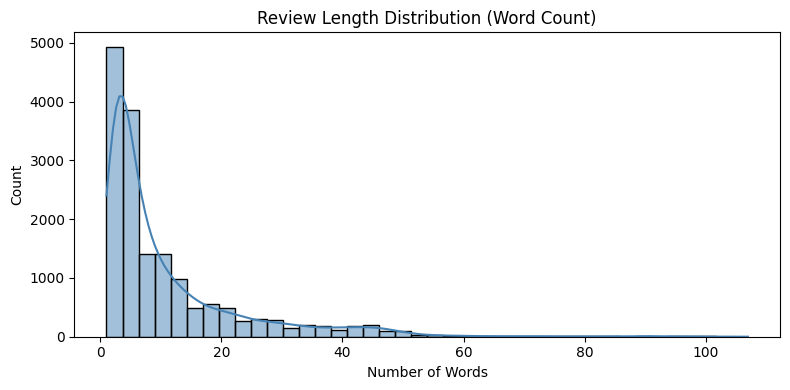

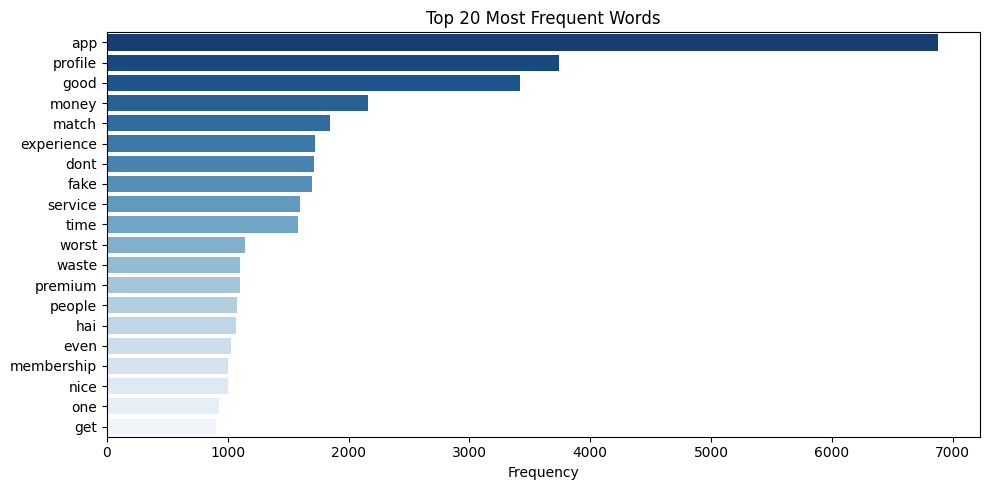

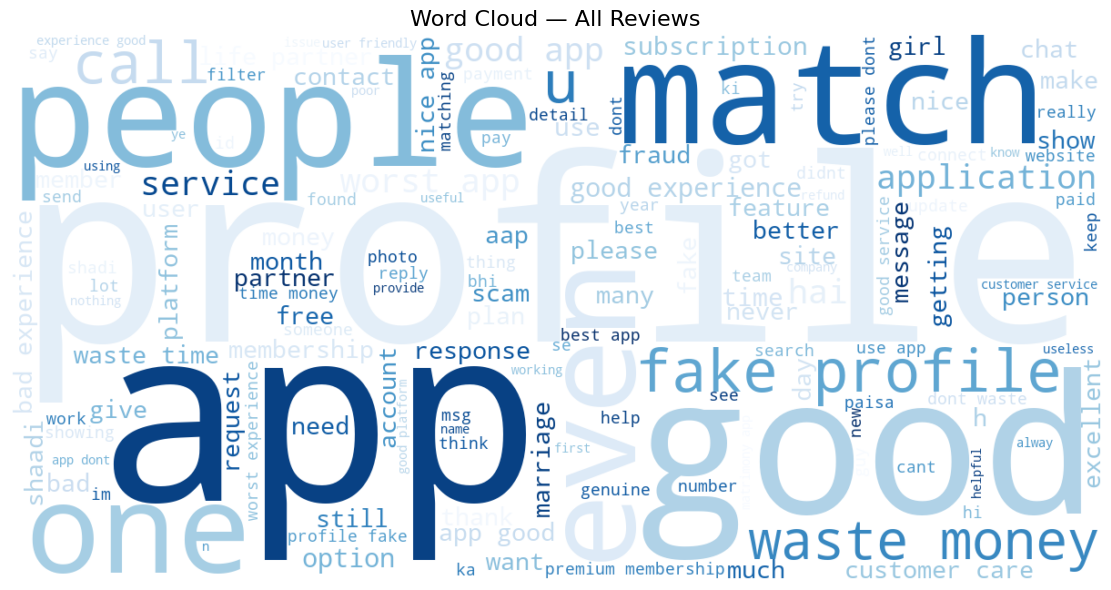

EDA plots saved.


In [4]:
from wordcloud import WordCloud
from collections import Counter

# --- 3.1 Review length distribution ---
plt.figure(figsize=(8, 4))
sns.histplot(df['review_length'], bins=40, kde=True, color='steelblue')
plt.title('Review Length Distribution (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('eda_review_length.png', dpi=150)
plt.show()

# --- 3.2 Top 20 most frequent words ---
all_words = " ".join(df['clean_review']).split()
word_freq = Counter(all_words).most_common(20)
words_plot, counts_plot = zip(*word_freq)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts_plot), y=list(words_plot), palette='Blues_r')
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig('eda_top_words.png', dpi=150)
plt.show()

# --- 3.3 Word cloud ---
wc_text = " ".join(df['clean_review'])
wc = WordCloud(width=1200, height=600, background_color='white',
               max_words=150, colormap='Blues').generate(wc_text)

plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — All Reviews', fontsize=16)
plt.tight_layout()
plt.savefig('eda_wordcloud.png', dpi=150)
plt.show()

print("EDA plots saved.")


### SECTION 4: SENTIMENT ANALYSIS (VADER — Baseline Labels)



Sentiment Distribution:
sentiment
positive    9136
negative    4499
neutral     2705
Name: count, dtype: int64


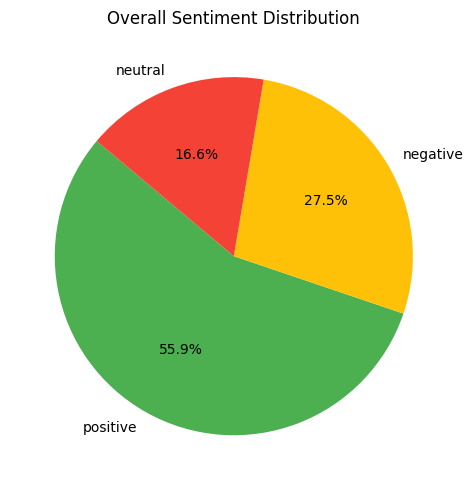


Positive reviews : 9136
Negative reviews : 4499


In [5]:
sia = SentimentIntensityAnalyzer()

df['sentiment_score'] = df['clean_review'].apply(
    lambda x: sia.polarity_scores(x)['compound']
)

def get_sentiment_label(score):
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['sentiment_score'].apply(get_sentiment_label)

print("\nSentiment Distribution:")
print(df['sentiment'].value_counts())

# Sentiment pie chart
plt.figure(figsize=(5, 5))
df['sentiment'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#4CAF50', '#FFC107', '#F44336'],
    startangle=140
)
plt.title('Overall Sentiment Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig('SDC_ sentiment_distribution_pie.png', dpi=150)
plt.show()

# Split by sentiment
positive_df = df[df['sentiment'] == 'positive'].copy()
negative_df = df[df['sentiment'] == 'negative'].copy()
print(f"\nPositive reviews : {len(positive_df)}")
print(f"Negative reviews : {len(negative_df)}")


### SECTION 5: IMBALANCE DETECTION & DATASET BALANCING  


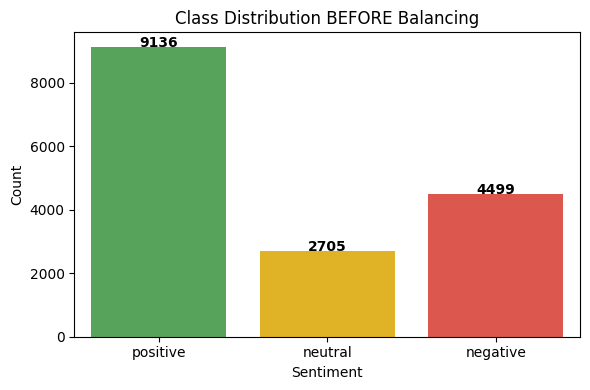


Class counts (before balancing):
sentiment
positive    9136
negative    4499
neutral     2705
Name: count, dtype: int64

Imbalance ratio (majority / minority): 3.38x
⚠  Significant imbalance detected — applying Random Oversampling.

Class counts (after balancing):
sentiment
positive    9136
neutral     9136
negative    9136
Name: count, dtype: int64


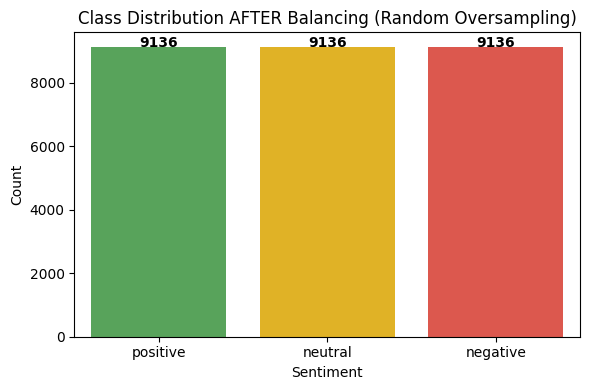

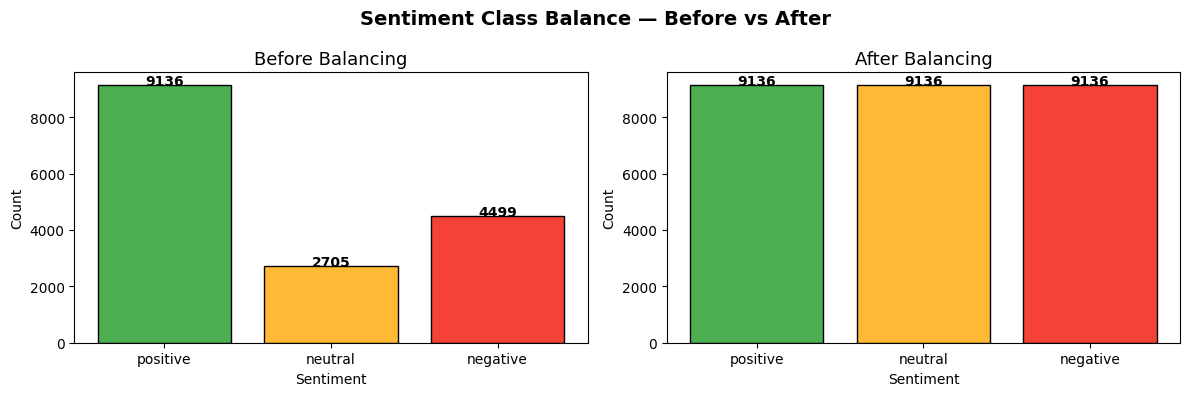


Balanced dataset size : 27408
Downstream sections (LDA, clustering, classification) will use df_balanced.


In [6]:
# Sentiment datasets are often skewed (e.g. far more positive than negative
# reviews). Training classifiers on imbalanced data causes them to over-predict
# the majority class. We detect the imbalance, visualise it, then apply
# Random Oversampling to create a balanced training set.
#
# Strategy chosen — Random Oversampling (minority classes duplicated with
# replacement to match the majority class count):
#   • Preserves all original samples (no information loss).
#   • Simple, effective baseline before trying SMOTE or augmentation.
#   • Balancing is applied ONLY to the training split so the test set
#     still reflects the real-world distribution.
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.utils import resample

# --- 5.1 Visualise class distribution BEFORE balancing ---
counts_before = df['sentiment'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=counts_before.index, y=counts_before.values,
            order=['positive', 'neutral', 'negative'],
            palette=['#4CAF50', '#FFC107', '#F44336'])
for i, v in enumerate(counts_before[['positive', 'neutral', 'negative']].values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.title('Class Distribution BEFORE Balancing')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('SDC_imbalance_before.png', dpi=150)
plt.show()

# --- 5.2 Compute imbalance ratio ---
majority_count = counts_before.max()
minority_count = counts_before.min()
imbalance_ratio = majority_count / minority_count
print(f"\nClass counts (before balancing):\n{counts_before}")
print(f"\nImbalance ratio (majority / minority): {imbalance_ratio:.2f}x")

if imbalance_ratio > 1.5:
    print("⚠  Significant imbalance detected — applying Random Oversampling.")
else:
    print("✓  Dataset is reasonably balanced — oversampling still applied for robustness.")

# --- 5.3 Random Oversampling on the full df (used for topic models & EDA) ---
target_count = majority_count  # upsample all classes to match the largest class

balanced_parts = []
for label in ['positive', 'neutral', 'negative']:
    class_df = df[df['sentiment'] == label]
    if len(class_df) < target_count:
        class_df_resampled = resample(
            class_df,
            replace=True,
            n_samples=target_count,
            random_state=42
        )
    else:
        class_df_resampled = class_df   # majority class — keep as-is
    balanced_parts.append(class_df_resampled)

df_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nClass counts (after balancing):\n{df_balanced['sentiment'].value_counts()}")

# --- 5.4 Visualise AFTER balancing ---
counts_after = df_balanced['sentiment'].value_counts()

plt.figure(figsize=(6, 4))
sns.barplot(x=counts_after.index, y=counts_after.values,
            order=['positive', 'neutral', 'negative'],
            palette=['#4CAF50', '#FFC107', '#F44336'])
for i, v in enumerate(counts_after[['positive', 'neutral', 'negative']].values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.title('Class Distribution AFTER Balancing (Random Oversampling)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('SDC_imbalance_after.png', dpi=150)
plt.show()

# --- 5.5 Side-by-side before / after comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
order = ['positive', 'neutral', 'negative']
colors = ['#4CAF50', '#FFB935', '#F44336']

for ax, counts, title in zip(
    axes,
    [counts_before, counts_after],
    ['Before Balancing', 'After Balancing']
):
    vals = [counts.get(s, 0) for s in order]
    bars = ax.bar(order, vals, color=colors, edgecolor='black')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 5, str(val),
                ha='center', fontweight='bold', fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Sentiment')
    ax.set_ylabel('Count')

plt.suptitle('Sentiment Class Balance — Before vs After', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('SDC_imbalance_comparison.png', dpi=150)
plt.show()

# Re-derive sentiment subsets from balanced df (used in LDA sections below)
positive_df = df_balanced[df_balanced['sentiment'] == 'positive'].copy()
negative_df = df_balanced[df_balanced['sentiment'] == 'negative'].copy()

print(f"\nBalanced dataset size : {len(df_balanced)}")
print("Downstream sections (LDA, clustering, classification) will use df_balanced.")


### SECTION 7: TOPIC MODELING — LDA


In [7]:
def print_topics(model, vectorizer, n_top_words=10, label=""):
    words = vectorizer.get_feature_names_out()
    print(f"\n{'='*40}")
    print(f"Topics — {label}")
    print(f"{'='*40}")
    for topic_idx, topic in enumerate(model.components_):
        top_words = [words[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"  Topic {topic_idx + 1}: {top_words}")

# --- 5.1 LDA on positive reviews ---
vectorizer_pos = CountVectorizer(max_df=0.9, min_df=10)
x_pos = vectorizer_pos.fit_transform(positive_df['clean_review'])
lda_pos = LatentDirichletAllocation(n_components=5, random_state=42)
lda_pos.fit(x_pos)
print_topics(lda_pos, vectorizer_pos, label="Positive Reviews (LDA)")

# --- 5.2 LDA on negative reviews ---
vectorizer_neg = CountVectorizer(max_df=0.9, min_df=10)
x_neg = vectorizer_neg.fit_transform(negative_df['clean_review'])
lda_neg = LatentDirichletAllocation(n_components=5, random_state=42)
lda_neg.fit(x_neg)
print_topics(lda_neg, vectorizer_neg, label="Negative Reviews (LDA)")



Topics — Positive Reviews (LDA)
  Topic 1: ['app', 'use', 'easy', 'profile', 'option', 'like', 'good', 'site', 'better', 'best']
  Topic 2: ['profile', 'even', 'premium', 'match', 'member', 'customer', 'membership', 'dont', 'app', 'get']
  Topic 3: ['app', 'good', 'partner', 'best', 'match', 'life', 'platform', 'find', 'excellent', 'nice']
  Topic 4: ['good', 'experience', 'nice', 'service', 'application', 'app', 'great', 'user', 'friendly', 'response']
  Topic 5: ['app', 'free', 'money', 'hai', 'dont', 'time', 'please', 'chat', 'waste', 'nhi']

Topics — Negative Reviews (LDA)
  Topic 1: ['profile', 'app', 'match', 'premium', 'number', 'show', 'option', 'membership', 'even', 'filter']
  Topic 2: ['fake', 'app', 'profile', 'money', 'dont', 'worst', 'time', 'waste', 'people', 'fraud']
  Topic 3: ['hai', 'bad', 'experience', 'bhi', 'app', 'nhi', 'koi', 'ke', 'ki', 'se']
  Topic 4: ['money', 'waste', 'profile', 'time', 'app', 'match', 'call', 'dont', 'account', 'get']
  Topic 5: ['app', '

### SECTION 8: TOPIC MODELING — BERTopic


In [10]:
# ── GPU check ─────────────────────────────────────────────────
use_cuda = torch.cuda.is_available()
device_name = torch.cuda.get_device_name(0) if use_cuda else "CPU"
print("=" * 60)
print("SECTION 8: TOPIC MODELING — BERTopic")
print("=" * 60)
print(f"Device : {'GPU (' + device_name + ')' if use_cuda else 'CPU'}")
if use_cuda:
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM   : {vram:.1f} GB")

# ── BERTopic setup ────────────────────────────────────────────
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

print("Loading sentence-transformer model: all-MiniLM-L6-v2 ...")
embedding_model = SentenceTransformer("all-MiniLM-L6-v2",
                                       device='cuda' if use_cuda else 'cpu')
print(f"  Model loaded on: {'GPU' if use_cuda else 'CPU'}")

print("\nRunning BERTopic (embeddings + UMAP + HDBSCAN)...")
bert_topic_model = BERTopic(
    embedding_model=embedding_model,
    language="english",
    calculate_probabilities=True,
    verbose=True,
    nr_topics="auto",
    min_topic_size=20
)

review_docs = df_balanced['clean_review'].tolist()
topics, probs = bert_topic_model.fit_transform(review_docs)
df_balanced['bertopic_topic'] = topics

# ── Topic summary ─────────────────────────────────────────────
topic_info = bert_topic_model.get_topic_info()
n_topics = len(topic_info[topic_info['Topic'] != -1])
n_outliers = (df_balanced['bertopic_topic'] == -1).sum()

print(f"\n{'='*50}")
print(f"BERTopic Results:")
print(f"  Topics found  : {n_topics}")
print(f"  Outlier docs  : {n_outliers} ({n_outliers/len(df_balanced)*100:.1f}%)")
print(f"{'='*50}")
print("\nTop 15 topics:")
print(topic_info.head(16).to_string(index=False))

# Top words per topic (printed cleanly)
print("\nDetailed top-words per topic (top 10):")
for row in topic_info[topic_info['Topic'] != -1].head(10).itertuples():
    words = bert_topic_model.get_topic(row.Topic)
    word_list = [w for w, _ in words[:8]]
    print(f"  Topic {row.Topic:>3} (n={row.Count:>5}): {word_list}")

# ── Visualise topic sizes ─────────────────────────────────────
topic_info_filtered = topic_info[topic_info['Topic'] != -1].head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=topic_info_filtered, x='Topic', y='Count', palette='viridis')
plt.title('BERTopic — Top 10 Topic Sizes (Balanced Reviews)', fontsize=13)
plt.xlabel('Topic ID'); plt.ylabel('Number of Documents')
plt.tight_layout()
plt.savefig('bertopic_topic_sizes.png', dpi=150)
plt.close()
print("\nSaved → bertopic_topic_sizes.png")

# ── Interactive HTML exports ──────────────────────────────────
try:
    fig_bc = bert_topic_model.visualize_barchart(top_n_topics=12)
    fig_bc.write_html("bertopic_barchart.html")
    print("Saved → bertopic_barchart.html")
except Exception as e:
    print(f"Barchart HTML skipped: {e}")

try:
    fig_td = bert_topic_model.visualize_topics()
    fig_td.write_html("bertopic_intertopic_distance.html")
    print("Saved → bertopic_intertopic_distance.html")
except Exception as e:
    print(f"Intertopic distance HTML skipped: {e}")

# ── Sentiment distribution across topics ─────────────────────
topic_sentiment = df_balanced.groupby('bertopic_topic')['sentiment'].value_counts(normalize=True).unstack(fill_value=0)
top_topics = topic_info[topic_info['Topic'] != -1].head(8)['Topic'].tolist()
topic_sentiment_top = topic_sentiment.loc[topic_sentiment.index.isin(top_topics)]

if not topic_sentiment_top.empty and len(topic_sentiment_top) > 1:
    cols = [c for c in ['positive', 'neutral', 'negative'] if c in topic_sentiment_top.columns]
    topic_sentiment_top[cols].plot(
        kind='bar', figsize=(12, 5),
        color=['#4CAF50', '#FFC107', '#F44336'][:len(cols)]
    )
    plt.title('Sentiment Distribution Within Top BERTopic Topics', fontsize=13)
    plt.xlabel('Topic ID'); plt.ylabel('Proportion')
    plt.xticks(rotation=0); plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.savefig('bertopic_sentiment_per_topic.png', dpi=150)
    plt.close()
    print("Saved → bertopic_sentiment_per_topic.png")




SECTION 8: TOPIC MODELING — BERTopic
Device : GPU (NVIDIA GeForce RTX 2050)
VRAM   : 4.3 GB
Loading sentence-transformer model: all-MiniLM-L6-v2 ...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 379.45it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-11 16:33:06,354 - BERTopic - Embedding - Transforming documents to embeddings.


  Model loaded on: GPU

Running BERTopic (embeddings + UMAP + HDBSCAN)...


Batches: 100%|██████████| 857/857 [00:14<00:00, 58.37it/s] 
2026-03-11 16:33:21,333 - BERTopic - Embedding - Completed ✓
2026-03-11 16:33:21,334 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-11 16:33:34,652 - BERTopic - Dimensionality - Completed ✓
2026-03-11 16:33:34,654 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-11 16:39:23,875 - BERTopic - Cluster - Completed ✓
2026-03-11 16:39:23,881 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-11 16:39:24,577 - BERTopic - Representation - Completed ✓
2026-03-11 16:39:24,579 - BERTopic - Topic reduction - Reducing number of topics
2026-03-11 16:39:24,850 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-11 16:39:25,415 - BERTopic - Representation - Completed ✓
2026-03-11 16:39:25,426 - BERTopic - Topic reduction - Reduced number of topics from 429 to 277



BERTopic Results:
  Topics found  : 276
  Outlier docs  : 7825 (28.6%)

Top 15 topics:
 Topic  Count                                  Name                                                                                Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

### SECTION 7: PHASE 2 — RECENT 25% ANALYSIS & SENTIMENT TRENDS 



Total Reviews (balanced) : 27408
Recent 25%               : 6852

Overall Sentiment Distribution (%):
sentiment
positive    33.33
neutral     33.33
negative    33.33
Name: proportion, dtype: float64

Recent 25% Sentiment Distribution (%):
sentiment
neutral     33.51
negative    33.35
positive    33.14
Name: proportion, dtype: float64


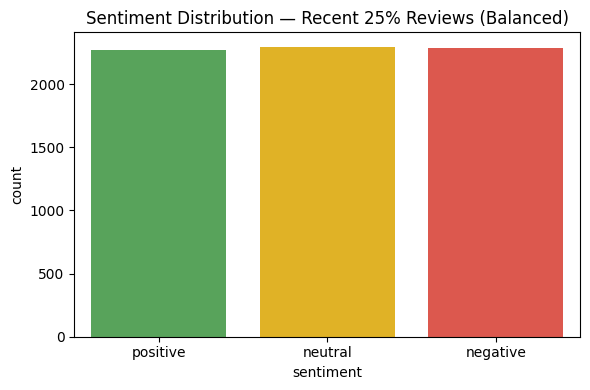

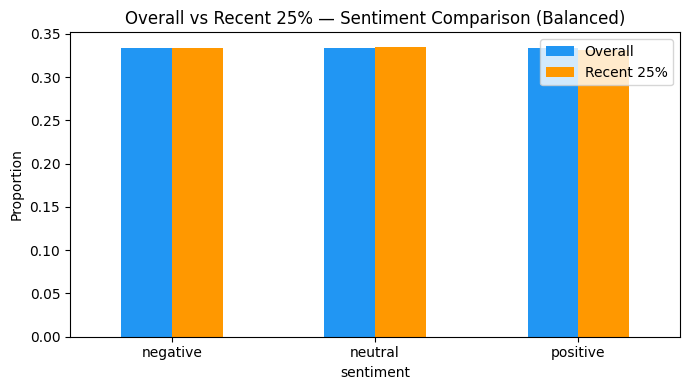

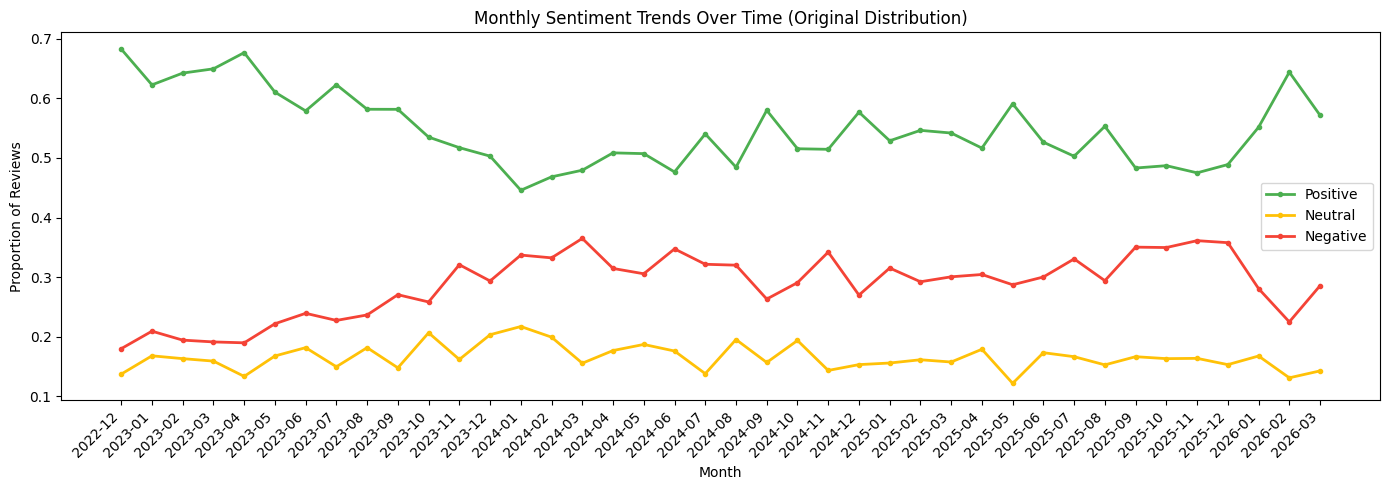

Time-series sentiment trend saved.

Topics — Recent 25% Reviews (LDA)
  Topic 1: ['hai', 'app', 'nhi', 'ke', 'ki', 'bhi', 'aap', 'paisa', 'koi', 'nahi']
  Topic 2: ['app', 'profile', 'money', 'fake', 'time', 'dont', 'worst', 'waste', 'service', 'experience']
  Topic 3: ['app', 'dont', 'call', 'user', 'much', 'download', 'money', 'star', 'class', 'नह']
  Topic 4: ['good', 'app', 'match', 'experience', 'nice', 'partner', 'service', 'application', 'platform', 'best']
  Topic 5: ['message', 'even', 'profile', 'app', 'premium', 'member', 'cant', 'contact', 'number', 'see']


In [11]:
# --- 9.1 Parse dates and sort (use original df for real time-series) ---
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date', ascending=False)

# Sync the Date column into df_balanced via original index
df_balanced['Date'] = df_balanced.index.map(
    lambda i: df.loc[i, 'Date'] if i in df.index else pd.NaT
)
df_balanced['Date'] = pd.to_datetime(df_balanced['Date'], errors='coerce')
df_balanced = df_balanced.sort_values(by='Date', ascending=False)

# --- 9.2 Extract recent 25% ---
recent_size = int(len(df_balanced) * 0.25)
recent_df = df_balanced.head(recent_size).copy()

print(f"\nTotal Reviews (balanced) : {len(df_balanced)}")
print(f"Recent 25%               : {len(recent_df)}")

print("\nOverall Sentiment Distribution (%):")
print(df_balanced['sentiment'].value_counts(normalize=True).mul(100).round(2))

print("\nRecent 25% Sentiment Distribution (%):")
print(recent_df['sentiment'].value_counts(normalize=True).mul(100).round(2))

# --- 9.3 Bar chart: sentiment in recent reviews ---
plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=recent_df,
              order=['positive', 'neutral', 'negative'],
              palette=['#4CAF50', '#FFC107', '#F44336'])
plt.title('Sentiment Distribution — Recent 25% Reviews (Balanced)')
plt.tight_layout()
plt.savefig('SDC_recent25_sentiment.png', dpi=150)
plt.show()

# --- 9.4 Side-by-side comparison ---
overall_counts = df_balanced['sentiment'].value_counts(normalize=True)
recent_counts  = recent_df['sentiment'].value_counts(normalize=True)

comparison_df = pd.DataFrame({
    'Overall':    overall_counts,
    'Recent 25%': recent_counts
}).fillna(0)

comparison_df.plot(kind='bar', figsize=(7, 4), color=['#2196F3', '#FF9800'])
plt.title('Overall vs Recent 25% — Sentiment Comparison (Balanced)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('SDC_sentiment_comparison.png', dpi=150)
plt.show()

# --- 9.5 TIME-SERIES sentiment trend using ORIGINAL df (real distribution) ---
# Note: Time-series uses the original unbalanced df so proportions reflect
# genuine opinion shifts, not artefacts of oversampling.
df['year_month'] = df['Date'].dt.to_period('M')

monthly_sentiment = (
    df.groupby(['year_month', 'sentiment'])
      .size()
      .unstack(fill_value=0)
)
monthly_sentiment_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0)
monthly_sentiment_pct.index = monthly_sentiment_pct.index.astype(str)

plt.figure(figsize=(14, 5))
for col, color in zip(['positive', 'neutral', 'negative'],
                      ['#4CAF50', '#FFC107', '#F44336']):
    if col in monthly_sentiment_pct.columns:
        plt.plot(monthly_sentiment_pct.index,
                 monthly_sentiment_pct[col],
                 label=col.capitalize(), color=color, linewidth=2, marker='o', markersize=3)

plt.title('Monthly Sentiment Trends Over Time (Original Distribution)')
plt.xlabel('Month')
plt.ylabel('Proportion of Reviews')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('SDC_sentiment_trend_over_time.png', dpi=150)
plt.show()
print("Time-series sentiment trend saved.")

# --- 9.6 LDA on recent 25% (balanced) ---
vectorizer_recent = CountVectorizer(max_df=0.9, min_df=5)
x_recent = vectorizer_recent.fit_transform(recent_df['clean_review'])
lda_recent = LatentDirichletAllocation(n_components=5, random_state=42)
lda_recent.fit(x_recent)
print_topics(lda_recent, vectorizer_recent, label="Recent 25% Reviews (LDA)")


### SECTION 10: REVIEW CLUSTERING — TF-IDF + K-MEANS  (uses df_balanced)



TF-IDF Matrix Shape: (27408, 2542)


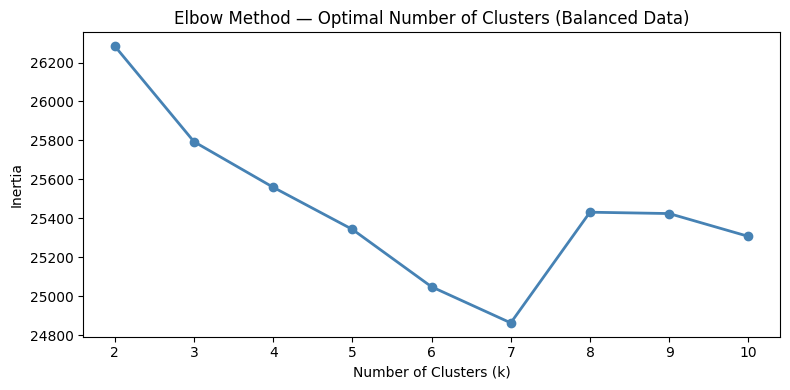


Cluster Top Terms (TF-IDF K-Means, Balanced Data):
  Cluster 0: ['hai', 'paisa', 'nahi', 'ke', 'app', 'bahut', 'bhi', 'hi', 'koi', 'ka']
  Cluster 1: ['profile', 'experience', 'match', 'service', 'fake', 'bad', 'application', 'nice', 'app', 'dont']
  Cluster 2: ['good', 'experience', 'service', 'app', 'application', 'platform', 'match', 'nice', 'partner', 'really']
  Cluster 3: ['app', 'best', 'nice', 'worst', 'fake', 'use', 'ever', 'profile', 'dont', 'partner']
  Cluster 4: ['money', 'waste', 'time', 'app', 'dont', 'worst', 'fake', 'profile', 'totally', 'bad']


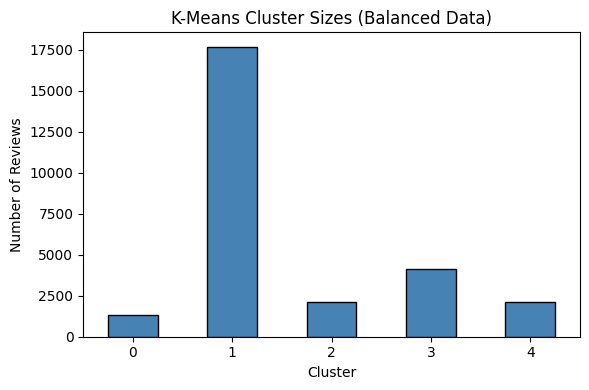


[Baseline] Logistic Regression Results (Balanced Data + class_weight):
Accuracy : 0.9144472820138636
              precision    recall  f1-score   support

    negative       0.91      0.93      0.92      1827
     neutral       0.89      0.96      0.92      1827
    positive       0.96      0.86      0.91      1828

    accuracy                           0.91      5482
   macro avg       0.92      0.91      0.91      5482
weighted avg       0.92      0.91      0.91      5482



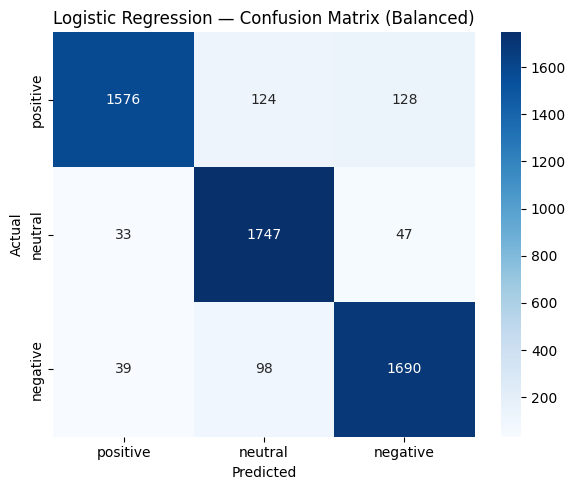

In [12]:
# --- 10.1 TF-IDF vectorisation ---
tfidf_vectorizer = TfidfVectorizer(max_df=0.9, min_df=10)
x_tfidf = tfidf_vectorizer.fit_transform(df_balanced['clean_review'])
print("\nTF-IDF Matrix Shape:", x_tfidf.shape)

# --- 10.2 Elbow method for optimal k ---
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(x_tfidf)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Elbow Method — Optimal Number of Clusters (Balanced Data)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('SDC_kmeans_elbow.png', dpi=150)
plt.show()

# --- 10.3 Apply K-Means (k=5) ---
kmeans = KMeans(n_clusters=5, random_state=42, n_init='auto')
df_balanced['cluster'] = kmeans.fit_predict(x_tfidf)

# --- 10.4 Interpret clusters via top terms ---
terms = tfidf_vectorizer.get_feature_names_out()
print("\nCluster Top Terms (TF-IDF K-Means, Balanced Data):")
for i in range(5):
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[-10:][::-1]
    print(f"  Cluster {i}: {[terms[j] for j in top_indices]}")

# --- 10.5 Cluster size bar chart ---
plt.figure(figsize=(6, 4))
df_balanced['cluster'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('K-Means Cluster Sizes (Balanced Data)')
plt.xlabel('Cluster')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('SDC_kmeans_cluster_sizes.png', dpi=150)
plt.show()


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: SENTIMENT CLASSIFICATION — LOGISTIC REGRESSION (BASELINE)
# Uses balanced data; class_weight='balanced' as additional safeguard
# ─────────────────────────────────────────────────────────────────────────────

X = df_balanced['clean_review']
y = df_balanced['sentiment']

lr_vectorizer = TfidfVectorizer(max_df=0.9, min_df=5)
X_vec = lr_vectorizer.fit_transform(X)

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_vec, y, test_size=0.2, random_state=42, stratify=y
)

# class_weight='balanced' adjusts loss weights inversely proportional to
# class frequency — provides an extra layer of protection against imbalance
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_model.fit(X_train_lr, y_train_lr)
y_pred_lr = lr_model.predict(X_test_lr)

print("\n[Baseline] Logistic Regression Results (Balanced Data + class_weight):")
print("Accuracy :", accuracy_score(y_test_lr, y_pred_lr))
print(classification_report(y_test_lr, y_pred_lr))

# Confusion matrix
cm = confusion_matrix(y_test_lr, y_pred_lr, labels=['positive', 'neutral', 'negative'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive', 'neutral', 'negative'],
            yticklabels=['positive', 'neutral', 'negative'])
plt.title('Logistic Regression — Confusion Matrix (Balanced)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('SDC_lr_confusion_matrix.png', dpi=150)
plt.show()


### SECTION 10: SENTIMENT-BASED 3-CLUSTER MAPPING



Sentiment Cluster Distribution:
sentiment_cluster
0    9136
1    9136
2    9136
Name: count, dtype: int64

Cluster 0 (Negative) — Sample Reviews:
  • sends disgusting message others behalf without consent
  • app suddenly stopped working
  • lot dummy account app looting money nothing took time subscription call wanted upgrade plan apart never asked feedback tried event pas successfully wasted hour life wait min connect dummy call call automatically ended waste min spoil time money would like yo give star rubbish app

Cluster 1 (Neutral) — Sample Reviews:
  • bilkul bakwas hai bhaiya yah sirf paisa theek nahin ka kam hai hindu ladka download karva liya aur paisa mang rahe hain fir photo dikhayenge ekadam badhiya hai bhai se achcha game khel ke apni mb kharab karna hai
  • west time responding profile scamer money demandand sex racket scamer
  • cant see message

Cluster 2 (Positive) — Sample Reviews:
  • helpful find soulmate
  • want try app buy subscription wise option talk someone 

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 304.58it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,Weighted F1
1,0.257014,0.226902,0.940720,0.940706
2,0.153819,0.211766,0.950980,0.951054
3,0.073948,0.198864,0.960100,0.960102


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.36s/it]
There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.la

  Validation Weighted F1: 0.9601
  Target F1 >= 0.9 reached. Stopping.

Best attempt : 1  |  Validation Weighted F1 : 0.9601


Loading weights: 100%|██████████| 201/201 [00:01<00:00, 154.45it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              



Evaluating best model on held-out test set...


Test Metrics: {'eval_loss': 0.18885089457035065, 'eval_model_preparation_time': 0.0096, 'eval_accuracy': 0.9602334914264867, 'eval_weighted_f1': 0.9602164467246007, 'eval_runtime': 26.4851, 'eval_samples_per_second': 206.984, 'eval_steps_per_second': 12.951}

Final Classification Report (Test Set — RoBERTa):
              precision    recall  f1-score   support

    negative       0.95      0.97      0.96      1827
     neutral       0.96      0.96      0.96      1827
    positive       0.96      0.95      0.96      1828

    accuracy                           0.96      5482
   macro avg       0.96      0.96      0.96      5482
weighted avg       0.96      0.96      0.96      5482



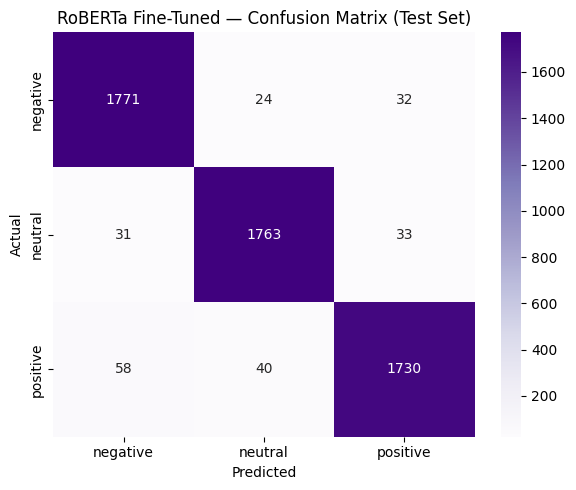

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.32s/it]


Best model saved → ./SDC_best_sentiment_model


In [15]:
sentiment_cluster_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df_balanced['sentiment_cluster'] = df_balanced['sentiment'].map(sentiment_cluster_map)

print("\nSentiment Cluster Distribution:")
print(df_balanced['sentiment_cluster'].value_counts().sort_index())


cluster_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
for cid in [0, 1, 2]:
    print(f"\nCluster {cid} ({cluster_names[cid]}) — Sample Reviews:")
    for rev in df_balanced[df_balanced['sentiment_cluster'] == cid]['clean_review'].head(3).tolist():
        print(f"  • {rev}")


# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13: TRANSFORMER FINE-TUNING — RoBERTa (GPU/CPU)
# Uses df_balanced; class weights applied inside a custom Trainer subclass
# to further guard against any residual imbalance in the training split.
# ─────────────────────────────────────────────────────────────────────────────

label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label  = {0: 'negative', 1: 'neutral', 2: 'positive'}

bert_df = df_balanced.dropna(subset=['clean_review', 'sentiment']).copy()
bert_df = bert_df[bert_df['sentiment'].isin(label2id.keys())]

texts  = bert_df['clean_review'].astype(str).tolist()
labels = bert_df['sentiment'].map(label2id).astype(int).tolist()

# Train / Val / Test split (64 / 16 / 20)
X_train_full, X_test_b, y_train_full, y_test_b = train_test_split(
    texts, labels, test_size=0.2, random_state=42, stratify=labels
)
X_train_b, X_val_b, y_train_b, y_val_b = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

BERT_MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

use_cuda = torch.cuda.is_available()
device   = torch.device("cuda" if use_cuda else "cpu")
print(f"\nTraining device : {device}")
if use_cuda:
    print("GPU             :", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True


class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(
            texts, truncation=True, padding=True, max_length=max_len
        )
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = SentimentDataset(X_train_b, y_train_b, tokenizer)
val_dataset   = SentimentDataset(X_val_b,   y_val_b,   tokenizer)
test_dataset  = SentimentDataset(X_test_b,  y_test_b,  tokenizer)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':    accuracy_score(labels, preds),
        'weighted_f1': f1_score(labels, preds, average='weighted')
    }


def build_training_args(output_dir, train_mode=True, epochs=None,
                        train_bs=None, eval_bs=None, lr=None, seed=None):
    supported = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
    kw = {'output_dir': output_dir}
    if train_mode:
        kw.update({'num_train_epochs': epochs, 'learning_rate': lr, 'weight_decay': 0.01})
    kw['per_device_eval_batch_size'] = eval_bs
    if train_mode:
        kw['per_device_train_batch_size'] = train_bs

    strat_key = 'evaluation_strategy' if 'evaluation_strategy' in supported else 'eval_strategy'
    if strat_key in supported:
        kw[strat_key] = 'epoch'

    bool_flags = {
        'save_strategy':           'epoch'  if train_mode else None,
        'load_best_model_at_end':  True     if train_mode else None,
        'metric_for_best_model':   'weighted_f1' if train_mode else None,
        'greater_is_better':       True     if train_mode else None,
        'do_eval':                 True,
        'logging_steps':           50,
        'fp16':                    use_cuda,
        'dataloader_pin_memory':   use_cuda,
        'save_safetensors':        True,
        'report_to':               'none',
    }
    if train_mode and seed is not None:
        bool_flags['seed'] = seed

    for k, v in bool_flags.items():
        if v is not None and k in supported:
            kw[k] = v

    return TrainingArguments(**kw)


# ---- Class weights for loss function (extra imbalance safeguard) ----
from collections import Counter
import torch.nn as nn

train_label_counts = Counter(y_train_b)
total_train = sum(train_label_counts.values())
# Weight = total / (n_classes * class_count)  — higher weight for rarer classes
class_weights = torch.tensor(
    [total_train / (3 * train_label_counts[i]) for i in range(3)],
    dtype=torch.float
)
print(f"\nClass weights for loss: {class_weights.tolist()}")


class WeightedTrainer(Trainer):
    """Custom Trainer that applies per-class weights to the cross-entropy loss."""
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        weights = class_weights.to(logits.device)
        loss_fn = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def build_trainer(model, args, eval_dataset, compute_metrics_fn,
                  train_dataset=None, callbacks=None):
    supported = set(inspect.signature(Trainer.__init__).parameters.keys())
    kw = {'model': model, 'args': args,
          'eval_dataset': eval_dataset, 'compute_metrics': compute_metrics_fn}
    if train_dataset is not None:
        kw['train_dataset'] = train_dataset
    if callbacks is not None:
        kw['callbacks'] = callbacks
    tok_key = 'tokenizer' if 'tokenizer' in supported else 'processing_class'
    kw[tok_key] = tokenizer
    # Use WeightedTrainer when training, standard Trainer for eval-only
    trainer_cls = WeightedTrainer if train_dataset is not None else Trainer
    return trainer_cls(**kw)


# ---- Retraining loop ----
TARGET_F1         = 0.90
MAX_ATTEMPTS      = 4
search_space      = [
    {'lr': 2e-5,  'epochs': 3, 'seed': 42},
    {'lr': 3e-5,  'epochs': 4, 'seed': 52},
    {'lr': 1.5e-5,'epochs': 5, 'seed': 62},
    {'lr': 2.5e-5,'epochs': 4, 'seed': 72},
]

best_f1        = -1.0
best_attempt   = -1
best_model_dir = None

for attempt_idx, config in enumerate(search_space[:MAX_ATTEMPTS], start=1):
    print(f"\n===== Retraining Attempt {attempt_idx}/{MAX_ATTEMPTS} =====")
    print(f"  lr={config['lr']}  epochs={config['epochs']}  seed={config['seed']}")

    out_dir = f"./bert_output_attempt_{attempt_idx}"
    os.makedirs(out_dir, exist_ok=True)

    try:
        bert_model = AutoModelForSequenceClassification.from_pretrained(
            BERT_MODEL_NAME,
            num_labels=3, id2label=id2label, label2id=label2id,
            ignore_mismatched_sizes=True, use_safetensors=True
        )
    except Exception as e:
        print(f"  Safetensors load failed ({e}). Using config init.")
        cfg = AutoConfig.from_pretrained(
            BERT_MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
        )
        bert_model = AutoModelForSequenceClassification.from_config(cfg)

    t_args = build_training_args(
        out_dir, train_mode=True,
        epochs=config['epochs'],
        train_bs=16 if use_cuda else 8,
        eval_bs=16 if use_cuda else 8,
        lr=config['lr'],
        seed=config['seed']
    )

    trainer = build_trainer(
        model=bert_model, args=t_args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        compute_metrics_fn=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()
    eval_res    = trainer.evaluate()
    current_f1  = eval_res.get('eval_weighted_f1', -1.0)
    print(f"  Validation Weighted F1: {current_f1:.4f}")

    if current_f1 > best_f1:
        best_f1        = current_f1
        best_attempt   = attempt_idx
        best_model_dir = trainer.state.best_model_checkpoint or out_dir

    if current_f1 >= TARGET_F1:
        print(f"  Target F1 >= {TARGET_F1} reached. Stopping.")
        break

print(f"\nBest attempt : {best_attempt}  |  Validation Weighted F1 : {best_f1:.4f}")


# ---- Final evaluation on held-out test set ----
if not best_model_dir:
    raise RuntimeError("No best checkpoint found — check training logs.")

best_model = AutoModelForSequenceClassification.from_pretrained(
    best_model_dir, use_safetensors=True
)
eval_args = build_training_args(
    './bert_output_best_eval', train_mode=False,
    eval_bs=16 if use_cuda else 8
)
best_trainer = build_trainer(
    model=best_model, args=eval_args,
    eval_dataset=test_dataset,
    compute_metrics_fn=compute_metrics
)

print("\nEvaluating best model on held-out test set...")
test_metrics = best_trainer.evaluate(eval_dataset=test_dataset)
print("Test Metrics:", test_metrics)

pred_output = best_trainer.predict(test_dataset)
y_pred_bert = np.argmax(pred_output.predictions, axis=-1)

print("\nFinal Classification Report (Test Set — RoBERTa):")
print(classification_report(y_test_b, y_pred_bert,
                             target_names=['negative', 'neutral', 'positive']))

# Confusion matrix for transformer model
cm_bert = confusion_matrix(y_test_b, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Purples',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('RoBERTa Fine-Tuned — Confusion Matrix (Test Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('SDC_roberta_confusion_matrix.png', dpi=150)
plt.show()

# ---- Save best model ----
tokenizer.save_pretrained('./SDC_best_sentiment_model')
best_model.save_pretrained('./SDC_best_sentiment_model', safe_serialization=True)
print("\nBest model saved → ./SDC_best_sentiment_model")


### SECTION 14: INSIGHT SUMMARY


In [16]:
print("\n" + "="*60)
print("INSIGHT SUMMARY")
print("="*60)

# Original distribution (before balancing)
orig_counts   = df['sentiment'].value_counts()
orig_total    = len(df)
print(f"\nOriginal dataset ({orig_total} reviews — real distribution):")
for label in ['positive', 'neutral', 'negative']:
    pct = orig_counts.get(label, 0) / orig_total * 100
    print(f"  {label.capitalize():<10}: {pct:.1f}%")

# Balanced distribution
bal_total     = len(df_balanced)
bal_counts    = df_balanced['sentiment'].value_counts()
print(f"\nBalanced dataset ({bal_total} reviews — after oversampling):")
for label in ['positive', 'neutral', 'negative']:
    pct = bal_counts.get(label, 0) / bal_total * 100
    print(f"  {label.capitalize():<10}: {pct:.1f}%")

# Recent 25% (from balanced df)
recent_pct_pos = (recent_df['sentiment'] == 'positive').sum() / len(recent_df) * 100
recent_pct_neg = (recent_df['sentiment'] == 'negative').sum() / len(recent_df) * 100
print(f"\nRecent 25% of balanced reviews:")
print(f"  Positive             : {recent_pct_pos:.1f}%")
print(f"  Negative             : {recent_pct_neg:.1f}%")

orig_pct_pos = orig_counts.get('positive', 0) / orig_total * 100
shift = recent_pct_pos - orig_pct_pos
direction = "improved" if shift > 0 else "declined"
print(f"\nSentiment shift (recent vs original overall): {shift:+.1f}% — sentiment has {direction}.")
print(f"\nImbalance ratio (original)  : {orig_counts.max() / orig_counts.min():.2f}x → resolved by oversampling.")
print(f"\nBest RoBERTa model validation F1   : {best_f1:.4f}")
print(f"Saved to                           : ./best_sentiment_model")
print("\nAll plots saved as .png files in the working directory.")
print("BERTopic interactive HTML files saved for presentation use.")



INSIGHT SUMMARY

Original dataset (16340 reviews — real distribution):
  Positive  : 55.9%
  Neutral   : 16.6%
  Negative  : 27.5%

Balanced dataset (27408 reviews — after oversampling):
  Positive  : 33.3%
  Neutral   : 33.3%
  Negative  : 33.3%

Recent 25% of balanced reviews:
  Positive             : 33.1%
  Negative             : 33.3%

Sentiment shift (recent vs original overall): -22.8% — sentiment has declined.

Imbalance ratio (original)  : 3.38x → resolved by oversampling.

Best RoBERTa model validation F1   : 0.9601
Saved to                           : ./best_sentiment_model

All plots saved as .png files in the working directory.
BERTopic interactive HTML files saved for presentation use.
